# Imports and constants

In [2]:
import numpy as np
from numpy.linalg import norm as norm
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':13})

# CONSTANTS
RADIUS = 6378 # m
MAGNETIC_FIELD = 3.11e-5 # T

ELEMENTARY_CHARGE = 1.602e-19 # C

ENERGY_ELECTRON = 100e3 * 1.602e-19 # J
MASS_ELECTRON = 9.109e-31 # kg
ENERGY_PROTON = 100 * 1.602e-19 # J
MASS_PROTON = 1.673e-27 # kg

# COMPUTE GYRATION PERIOD TO FIND TIME OPTIMAL TIME STEP VALUE (L=4)
GYRO_FREQUENCY_ELECTRON = ELEMENTARY_CHARGE*MAGNETIC_FIELD/(4**3)/MASS_ELECTRON
GYRO_FREQUENCY_PROTON = ELEMENTARY_CHARGE*MAGNETIC_FIELD/(4**3)/MASS_PROTON

# Electron

## Trajectory

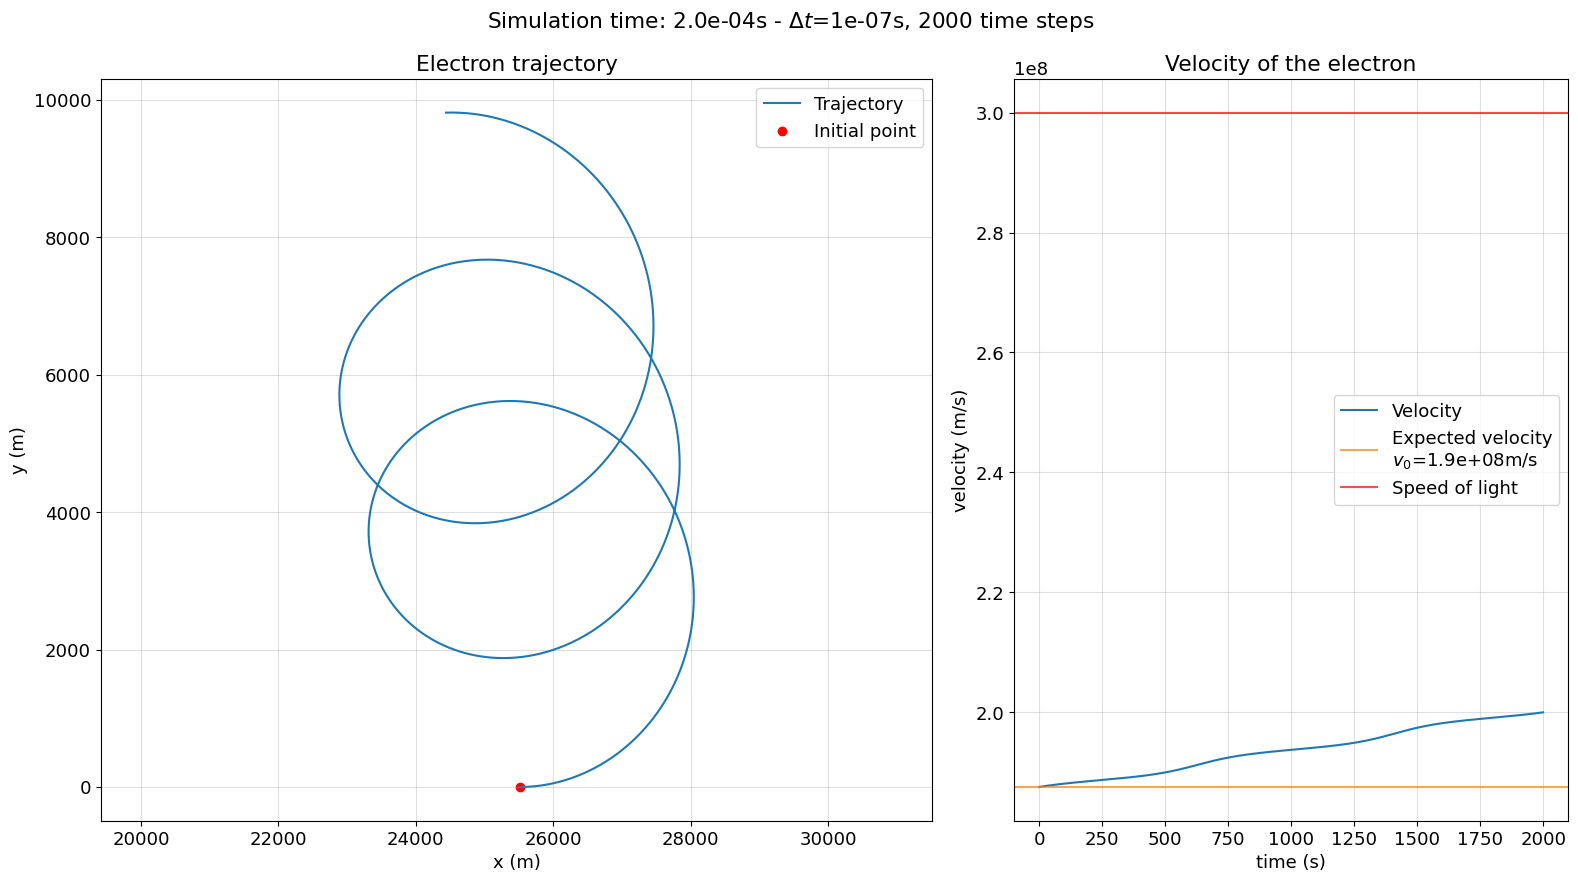

In [3]:
# CONSTANTS FOR INTEGRATION
STEPS = 2000
dt = 1e-7
C_ELECTRON = - dt * ELEMENTARY_CHARGE / MASS_ELECTRON * MAGNETIC_FIELD * RADIUS**3

# POSITION ARRAYS (AT t=0, L=4)
r_ELECTRON = np.empty((STEPS, 2))
r_ELECTRON[0] = np.array([4*RADIUS, 0])

# VELOCITY ARRAYS (AT t=0, VELOCITY IS RADIAL)
v_ELECTRON = np.empty((STEPS, 2))
v_ELECTRON[0] = np.array([np.sqrt(2*ENERGY_ELECTRON/MASS_ELECTRON), 0])

for step in range(1, STEPS):
    
    # UPDATE ELECTRON VELOCITY
    v_ELECTRON[step, 0] = v_ELECTRON[step-1, 0] + C_ELECTRON*v_ELECTRON[step-1, 1]/norm(r_ELECTRON[step-1])**3
    v_ELECTRON[step, 1] = v_ELECTRON[step-1, 1] - C_ELECTRON*v_ELECTRON[step-1, 0]/norm(r_ELECTRON[step-1])**3

    # UPDATE ELECTRON POSITION
    r_ELECTRON[step] = r_ELECTRON[step-1] + dt * (v_ELECTRON[step-1] + v_ELECTRON[step])*0.5

fig, axs = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios':[0.6, 0.4]})
axs[0].plot(r_ELECTRON[1:, 0], r_ELECTRON[1:, 1], label='Trajectory')
axs[0].scatter(r_ELECTRON[0, 0], r_ELECTRON[0, 1], color='red', label='Initial point')
axs[0].set_title('Electron trajectory')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].legend()
axs[0].grid(alpha=.4)
axs[0].axis('equal')

axs[1].plot(range(STEPS), norm(v_ELECTRON, axis=1), label='Velocity')
axs[1].axhline(norm(v_ELECTRON[0]), label='Expected velocity\n' rf'$v_0$={norm(v_ELECTRON[0]):.1e}m/s', c='tab:orange', alpha=.7)
axs[1].axhline(3.0e8, label='Speed of light', c='red', alpha=.7)
if np.max(norm(v_ELECTRON, axis=1)) > 3.0e8:
    axs[1].fill_between(range(STEPS), 3.0e8, axs[1].get_ylim()[1], alpha=.2, color='red')
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('velocity (m/s)')
axs[1].legend()
axs[1].grid(alpha=.4)
axs[1].set_title('Velocity of the electron')

fig.suptitle(rf'Simulation time: {STEPS*dt:.1e}s - $\Delta t$={dt}s, {STEPS} time steps')
fig.tight_layout()
plt.show()

## Drift velocity

In [4]:
phi_ELECTRON = np.unwrap(np.atan2(r_ELECTRON[:, 1], r_ELECTRON[:, 0]))
vDrift_ELECTRON = 4*RADIUS * np.polyfit(np.linspace(0, STEPS*dt, STEPS), phi_ELECTRON, 1)[0]
print(f'{vDrift_ELECTRON:.2e}')

2.82e+07


# Proton

## Trajectory

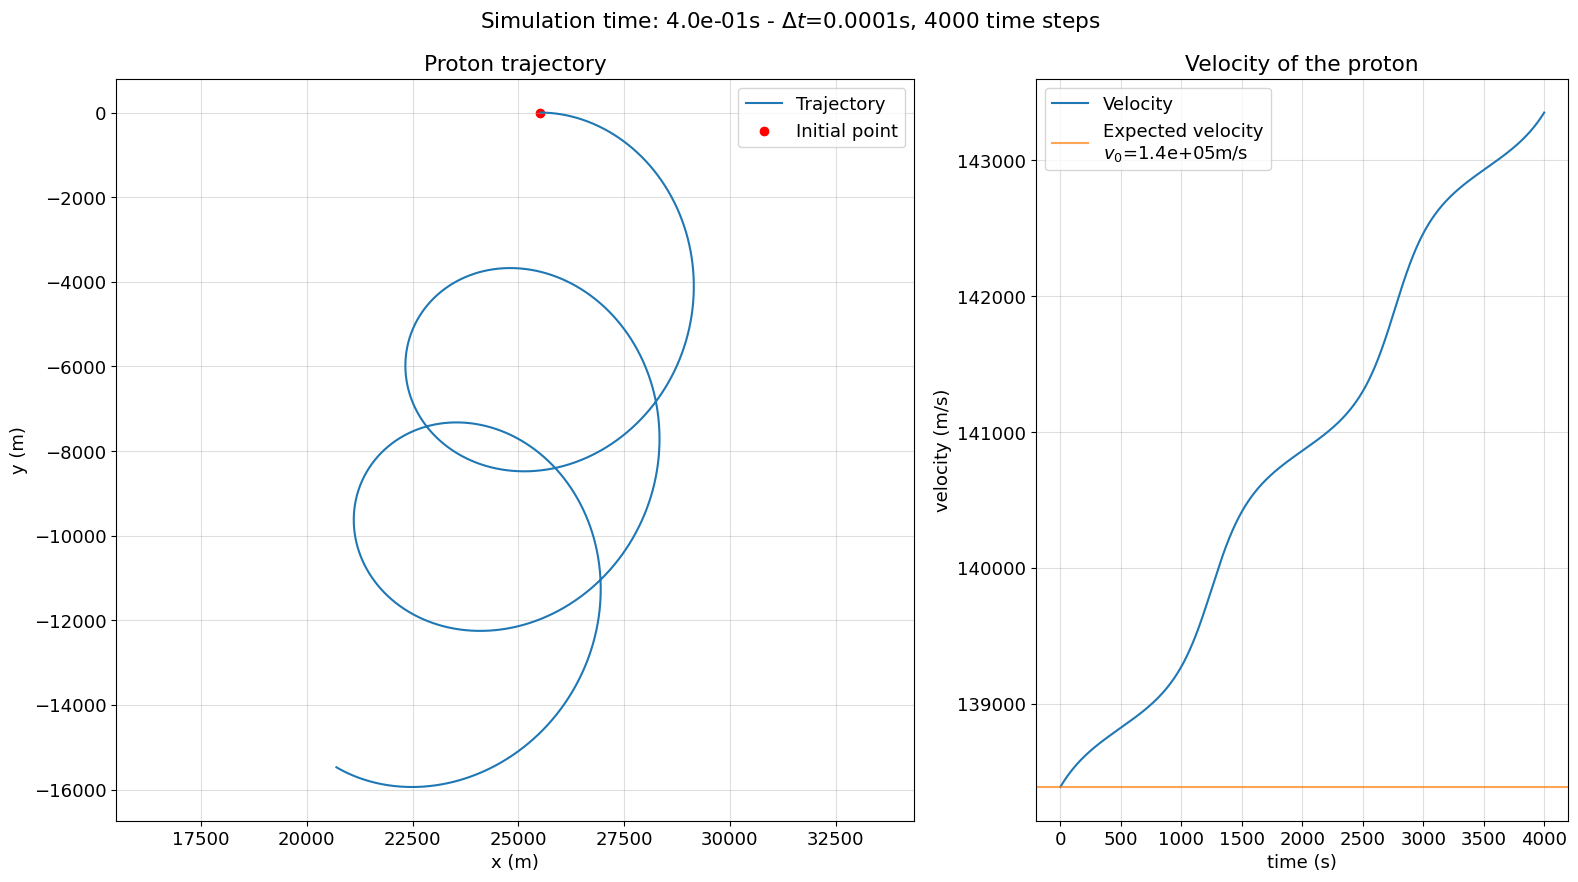

In [5]:
# CONSTANTS FOR INTEGRATION
STEPS = 4000
dt = 1e-4
C_PROTON = dt * ELEMENTARY_CHARGE / MASS_PROTON * MAGNETIC_FIELD * RADIUS**3

# POSITION ARRAYS (AT t=0, L=4)
r_PROTON = np.empty((STEPS, 2))
r_PROTON[0] = np.array([4*RADIUS, 0])

# VELOCITY ARRAYS (AT t=0, VELOCITY IS RADIAL)
v_PROTON = np.empty((STEPS, 2))
v_PROTON[0] = np.array([np.sqrt(2*ENERGY_PROTON/MASS_PROTON), 0])

for step in range(1, STEPS):
    
    # UPDATE PROTON VELOCITY
    v_PROTON[step, 0] = v_PROTON[step-1, 0] + C_PROTON*v_PROTON[step-1, 1]/norm(r_PROTON[step-1])**3
    v_PROTON[step, 1] = v_PROTON[step-1, 1] - C_PROTON*v_PROTON[step-1, 0]/norm(r_PROTON[step-1])**3

    # UPDATE PROTON POSITION
    r_PROTON[step] = r_PROTON[step-1] + dt * (v_PROTON[step-1] + v_PROTON[step])*0.5

fig, axs = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios':[0.6, 0.4]})
axs[0].plot(r_PROTON[1:, 0], r_PROTON[1:, 1], label='Trajectory')
axs[0].scatter(r_PROTON[0, 0], r_PROTON[0, 1], color='red', label='Initial point')
axs[0].set_title('Proton trajectory')
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
axs[0].legend()
axs[0].grid(alpha=.4)
axs[0].axis('equal')

axs[1].plot(range(STEPS), norm(v_PROTON, axis=1), label='Velocity')
axs[1].axhline(norm(v_PROTON[0]), label='Expected velocity\n' rf'$v_0$={norm(v_PROTON[0]):.1e}m/s', c='tab:orange', alpha=.7)
if np.max(norm(v_PROTON, axis=1)) > 3.0e8:
    axs[1].axhline(3.0e8, label='Speed of light', c='red', alpha=.7)
    axs[1].fill_between(range(STEPS), 3.0e8, axs[1].get_ylim()[1], alpha=.2, color='red')
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('velocity (m/s)')
axs[1].legend()
axs[1].grid(alpha=.4)
axs[1].set_title('Velocity of the proton')

fig.suptitle(rf'Simulation time: {STEPS*dt:.1e}s - $\Delta t$={dt}s, {STEPS} time steps')
fig.tight_layout()
plt.show()

## Drift velocity

In [6]:

phi_PROTON = np.unwrap(np.atan2(r_PROTON[:, 1], r_PROTON[:, 0]))
vDrift_PROTON = 4*RADIUS * np.polyfit(np.linspace(0, STEPS*dt, STEPS), phi_PROTON, 1)[0]
print(f'{vDrift_PROTON:.2e}')

-2.82e+04
